<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
print("Path to dataset files:", path)

100%|██████████| 119k/119k [00:00<00:00, 429kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumarajarshi/life-expectancy-who/versions/1


In [3]:
rng = np.random.default_rng()

In [47]:
df = pd.read_csv(f'{path}/Life Expectancy Data.csv')
df.drop(['Country', 'Year', 'Status'], inplace=True, axis=1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.columns = [col.strip().lower() for col in df.columns]
df.head()

,life expectancy,adult mortality,infant deaths,alcohol,percentage expenditure,hepatitis b,measles,bmi,under-five deaths,polio,total expenditure,diphtheria,hiv/aids,gdp,population,thinness 1-19 years,thinness 5-9 years,income composition of resources,schooling
0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# 04/

# Clustering



**Purpose / Why it's used:**

 - To measure the degree of similarity between objects.
 - To speed up further data processing.
 - To reduce the volume of stored data.
 - To detect outliers.
 - For feature selection (selecting one representative feature from each cluster).

```
If an algorithm uses a distance metric on a set of objects,
then the values of all features must be normalized beforehand.
```

In [34]:
standrtzt = lambda row: (row - row.mean()) / row.std() # normalization

## k-means

### Algorithm #1

In [53]:
from scipy.spatial import distance_matrix

clust_al_1 = df[['life expectancy', 'alcohol']].copy()
clust_al_1['life expectancy'] = standrtzt(clust_al_1['life expectancy'])
clust_al_1['alcohol'] = standrtzt(clust_al_1['alcohol'])

clust_al_1_dist = pd.DataFrame(
    data=distance_matrix(clust_al_1.values, clust_al_1.values),
    index=clust_al_1.index,
    columns=clust_al_1.index
)

clust_al_1_dist.loc[:10, :10]

,0,1,2,3,4,5,6,7,8,9,10
0,0.000000,0.579754,0.579754,0.625225,0.659328,0.704799,0.727534,0.784389,0.852583,0.875329,0.875318
1,0.579754,0.000000,0.000000,0.045471,0.079574,0.125045,0.147780,0.204679,0.272837,0.295603,0.295571
2,0.579754,0.000000,0.000000,0.045471,0.079574,0.125045,0.147780,0.204679,0.272837,0.295603,0.295571
3,0.625225,0.045471,0.045471,0.000000,0.034103,0.079574,0.102310,0.159226,0.227368,0.250139,0.250102
4,0.659328,0.079574,0.079574,0.034103,0.000000,0.045471,0.068206,0.125143,0.193267,0.216044,0.216001
5,0.704799,0.125045,0.125045,0.079574,0.045471,0.000000,0.022735,0.079729,0.147801,0.170588,0.170534
6,0.727534,0.147780,0.147780,0.102310,0.068206,0.022735,0.000000,0.057055,0.125070,0.147864,0.147801
7,0.784389,0.204679,0.204679,0.159226,0.125143,0.079729,0.057055,0.000000,0.068251,0.090942,0.090976
8,0.852583,0.272837,0.272837,0.227368,0.193267,0.147801,0.125070,0.068251,0.000000,0.022871,0.022735
9,0.875329,0.295603,0.295603,0.250139,0.216044,0.170588,0.147864,0.090942,0.022871,0.000000,0.002482


Text(0, 0.5, 'alcohol')

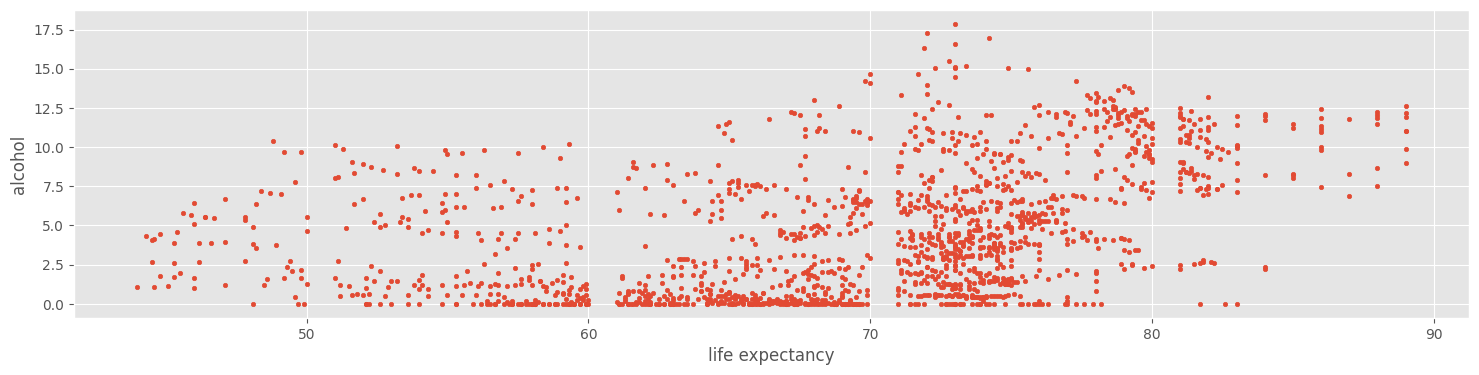

In [21]:
plt.figure(figsize=(18, 4))

plt.scatter(df['life expectancy'], df['alcohol'], s=10)
plt.xlabel('life expectancy')
plt.ylabel('alcohol')


In [22]:
df.shape

(1649, 19)